<a href="https://colab.research.google.com/github/rubenoliva-dominguez/curso_cartagena/blob/main/dia1/4_ejercicio_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio final

Escoge un dataset de regresión o clasificación (el que tu quieras) y diseña una red neuronal (de varias capas) para clasificarlo. El algoritmo de entrenamiento debe incluir algún mecanismo que monitorice el loss de validación para la selección del mejor modelo y algún método de regularización (dropout, $L_1$ o $L_2$). La red debe ser evaluada en un conjunto de test.

Si se usa regresión, recomiendo usar el MSE como función de pérdida (https://docs.pytorch.org/docs/stable/generated/torch.nn.MSELoss.html).

Ejemplos clasificación:
- https://archive.ics.uci.edu/dataset/109/wine (se predice `class`)
- https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic (se predice `diagnosis`)

Ejemplos regresión:
- https://www.kaggle.com/datasets/camnugent/california-housing-prices (tiene una variable categórica y una variable con NAs; se predice `median_house_value`)
- https://www.kaggle.com/datasets/heptapod/uci-ml-datasets (se predice `MEDV`)
- https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html

**Nota.** La red tiene que recibir como entrada un valor numérico. Puede ser que haya datasets con features con NAs o con features categóricas. Si hay NAs, se pueden o borrar las filas/columnas o si tenéis conocimientos de machine learning, podéis imputar los valores. Si hay features categóricas, se pueden pasar a valor numérico con una asignación simple (por ejemplo, si la feature es "color" y tiene los valores "rojo", "verde" y "azul", se pueden asignar los valores 0, 1 y 2 respectivamente).


In [ ]:
# Empezamos con el ejercicio

**Librerías**

In [40]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_wine
import copy
!pip install torchviz
from torchviz import make_dot
import matplotlib.pyplot as plt

**Dataset y dataloader de vinos**

In [7]:
# Importamos el dataset de manera guachi pistachi

from sklearn.datasets import load_wine
class WineDataset(Dataset):
  def __init__(self):
    data = load_wine()
    self.X = torch.tensor(
        data.data, dtype=torch.float32
    )  # (150, 4)
    self.y = torch.tensor(
              data.target, dtype=torch.long
    )  # (150,)

      # PyTorch necesita saber el tamaño del dataset
  def __len__(self):
      return self.X.shape[0]

      # PyTorch necesita poder indexar el dataset
  def __getitem__(self, idx):
      return self.X[idx], self.y[idx]

In [8]:
full_wine_dataset = WineDataset()

**MUESTRAS**

In [9]:
# ejemplos de muestras
for i in [1, 50, 100]:
    x, y = full_wine_dataset[i]
    print(f"Muestra {i}: x = {x}, y = {y}")

Muestra 1: x = tensor([1.3200e+01, 1.7800e+00, 2.1400e+00, 1.1200e+01, 1.0000e+02, 2.6500e+00,
        2.7600e+00, 2.6000e-01, 1.2800e+00, 4.3800e+00, 1.0500e+00, 3.4000e+00,
        1.0500e+03]), y = 0
Muestra 50: x = tensor([1.3050e+01, 1.7300e+00, 2.0400e+00, 1.2400e+01, 9.2000e+01, 2.7200e+00,
        3.2700e+00, 1.7000e-01, 2.9100e+00, 7.2000e+00, 1.1200e+00, 2.9100e+00,
        1.1500e+03]), y = 0
Muestra 100: x = tensor([1.2080e+01, 2.0800e+00, 1.7000e+00, 1.7500e+01, 9.7000e+01, 2.2300e+00,
        2.1700e+00, 2.6000e-01, 1.4000e+00, 3.3000e+00, 1.2700e+00, 2.9600e+00,
        7.1000e+02]), y = 1


**Longitud de la muestra**

In [13]:
len(full_wine_dataset)


178

**Definición de la red de vinotes**

In [25]:
# Vamos a añadir una capa lineal oculta con función de activación ReLU
class WineRed(nn.Module):
    def __init__(self, hidden_dim: int = 16):
        super().__init__()
        self.fc1 = nn.Linear(13, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 3)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.relu(self.fc1(x))   # (B, 16)
        logits = self.fc2(h)         # (B, 3)
        return logits

**Dividiendo el dataset en entrenamiento, validación y testeo de manera genial**

In [26]:
train_dataset, test_dataset, val_dataset = torch.utils.data.random_split(full_wine_dataset, [0.7, 0.2, 0.1], generator=torch.Generator().manual_seed(42))

In [34]:
# ejemplos de muestras
for i in [0, 1, 2]:
    x, y = train_dataset[i]
    print(f"Muestra {i}: x = {x}, y = {y}")

Muestra 0: x = tensor([1.2080e+01, 2.0800e+00, 1.7000e+00, 1.7500e+01, 9.7000e+01, 2.2300e+00,
        2.1700e+00, 2.6000e-01, 1.4000e+00, 3.3000e+00, 1.2700e+00, 2.9600e+00,
        7.1000e+02]), y = 1
Muestra 1: x = tensor([1.3230e+01, 3.3000e+00, 2.2800e+00, 1.8500e+01, 9.8000e+01, 1.8000e+00,
        8.3000e-01, 6.1000e-01, 1.8700e+00, 1.0520e+01, 5.6000e-01, 1.5100e+00,
        6.7500e+02]), y = 2
Muestra 2: x = tensor([1.1460e+01, 3.7400e+00, 1.8200e+00, 1.9500e+01, 1.0700e+02, 3.1800e+00,
        2.5800e+00, 2.4000e-01, 3.5800e+00, 2.9000e+00, 7.5000e-01, 2.8100e+00,
        5.6200e+02]), y = 1


**Instancia de modelito**

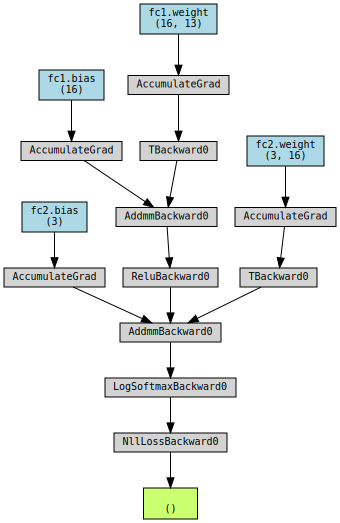

In [35]:
# Instanciamos el modelo y el loss
# En PyTorch, el loss y el modelo suelen ser instanciados por separado
model = WineRed()
criterion = nn.CrossEntropyLoss()

# Input dummy (batch size = 5)
x = torch.randn(3, 13, requires_grad=False)

# Forward
y = model(x)
# Loss
target = torch.tensor([1, 2, 1])  # clase verdadera
loss = criterion(y, target)


# Crear grafo computacional
dot = make_dot(loss, params=dict(model.named_parameters()))

# Mostrar o guardar
dot

**Dividimos en Batchecitos**

In [36]:
# esta función devuelve un iterador sobre batches
dataloader = DataLoader(full_wine_dataset, batch_size=16, shuffle=True)
# por otro lado, la red se ha definido para procesar batches de datos

**Juntando ingredientes en la Thermomix**

In [37]:
# Se debe instanciar modelo, loss y optimizador
# Si se dispone de GPU, mover el modelo a GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# La red se inicializa a pesos aleatorios cada vez que se instancia
model = WineRed().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

**Entrenando en épocas geniales**

Epoch 001 | train_loss = 1.0863 | eval_loss = 1.0862
Epoch 002 | train_loss = 1.0864 | eval_loss = 1.0862
Epoch 003 | train_loss = 1.0864 | eval_loss = 1.0862
Epoch 004 | train_loss = 1.0863 | eval_loss = 1.0862
Epoch 005 | train_loss = 1.0863 | eval_loss = 1.0862
Epoch 006 | train_loss = 1.0863 | eval_loss = 1.0861
Epoch 007 | train_loss = 1.0863 | eval_loss = 1.0861
Epoch 008 | train_loss = 1.0862 | eval_loss = 1.0861
Epoch 009 | train_loss = 1.0862 | eval_loss = 1.0861
Epoch 010 | train_loss = 1.0861 | eval_loss = 1.0860
Epoch 011 | train_loss = 1.0862 | eval_loss = 1.0860
Epoch 012 | train_loss = 1.0861 | eval_loss = 1.0860
Epoch 013 | train_loss = 1.0863 | eval_loss = 1.0860
Epoch 014 | train_loss = 1.0862 | eval_loss = 1.0860
Epoch 015 | train_loss = 1.0863 | eval_loss = 1.0860
Epoch 016 | train_loss = 1.0862 | eval_loss = 1.0860
Epoch 017 | train_loss = 1.0862 | eval_loss = 1.0860
Epoch 018 | train_loss = 1.0862 | eval_loss = 1.0861
Epoch 019 | train_loss = 1.0862 | eval_loss = 

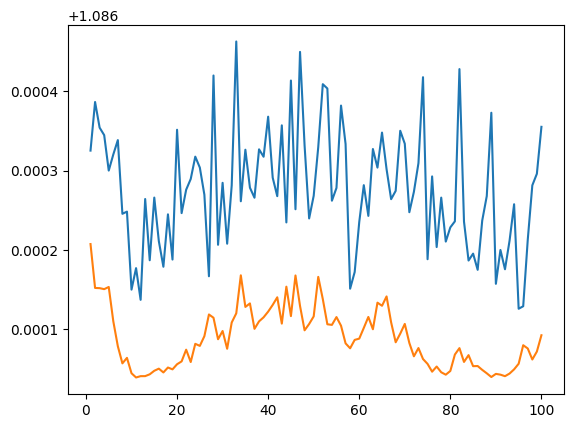

In [42]:
num_epochs = 100
# durante un número de epochs
train_losses = []
eval_losses = []
for epoch in range(1, num_epochs + 1):
    # poner el modelo en modo entrenamiento
    model.train()
    # para llevar la cuenta del loss
    running_loss = 0.0
    n_seen = 0
    n_seen_val = 0

    for xB, yB in dataloader:
        xB, yB = xB.to(device), yB.to(device)
        optimizer.zero_grad()      # reset gradientes
        logits = model(xB)         # forward
        loss = criterion(logits, yB)
        loss.backward()            # backward
        optimizer.step()           # update
        running_loss += loss.item() * xB.size(0) # para llevar la cuenta del loss
        n_seen += xB.size(0)           # para llevar la cuenta del loss
    epoch_loss = running_loss / n_seen
    # poner el modelo en modo validación
    model.eval()
    eval_loss = 0.0
    with torch.no_grad():
        for xB, yB in dataloader:
          xB, yB = xB.to(device), yB.to(device)
          logits = model(xB)         # forward
          loss = criterion(logits, yB)
          eval_loss += loss.item() * xB.size(0) # para llevar la cuenta del loss
          n_seen_val += xB.size(0)           # para llevar la cuenta del loss
    epocheval_loss = eval_loss / n_seen # loss medio en la epoch
    print(f"Epoch {epoch:03d} | train_loss = {epoch_loss:.4f} | eval_loss = {epocheval_loss:.4f}") # reportamos el loss
    train_losses.append(epoch_loss)
    eval_losses.append(epocheval_loss)

plt.plot(range(1, num_epochs+1), train_losses, range(1, num_epochs+1), eval_losses)
plt.show()